In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
import statsmodels.formula.api as smf

warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNetCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV

# from utils.utils import *
from utils.data_loader import load_data

# Loading data

In [2]:
final_clean_strained = load_data(db_level=0)

In [3]:
peak_curvs = final_clean_strained["PeakI Curvature"].apply(pd.Series)
peak_curvs.columns = [
    "PeakI Left Curvature",
    "PeakI Overall Curvature",
    "PeakI Right Curvature",
]
trough_curvs = final_clean_strained["TroughI Curvature"].apply(pd.Series)
trough_curvs.columns = [
    "TroughI Left Curvature",
    "TroughI Overall Curvature",
    "TroughI Right Curvature",
]
final_clean_strained = pd.concat(
    [final_clean_strained, peak_curvs, trough_curvs], axis=1
)

In [4]:
def split_by_mouse(
    data,
    split_on="Subject",
    stratify_on="Group",
    test_size=0.2,
    val_size=0.18,
    random_state=22,
    return_idx=False,
):
    mice = data[[split_on, stratify_on]].drop_duplicates().set_index(split_on)

    train, test = train_test_split(
        mice.index,
        test_size=test_size,
        shuffle=True,
        stratify=mice[stratify_on],
        random_state=random_state,
    )

    train_indices = data[split_on].isin(train)
    test_indices = data[split_on].isin(test)

    train2, val = train_test_split(
        train,
        test_size=val_size,
        shuffle=True,
        stratify=mice.loc[train]["Group"],
        random_state=random_state,
    )

    train2_indices = data[split_on].isin(train2)
    val_indices = data[split_on].isin(val)

    data["DataGroup"] = ""
    data.loc[train2_indices, "DataGroup"] = "Train"
    data.loc[val_indices, "DataGroup"] = "Validate"
    data.loc[test_indices, "DataGroup"] = "Test"
    if return_idx:
        return data, train_indices, train2_indices, val_indices, test_indices
    return data

# Train test split

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    FunctionTransformer,
    MinMaxScaler,
)


def RF_data_prep(
    data,
    num_features,
    cat_features,
    log_features,
    minmax_features,
    target="SynapsesPerIHC",
):
    X = data[num_features + cat_features + log_features + minmax_features]
    y = data[target]

    X_train, X_test, y_train, y_test = (
        X[data.DataGroup != "Test"],
        X[data.DataGroup == "Test"],
        y[data.DataGroup != "Test"],
        y[data.DataGroup == "Test"],
    )

    log_scale_pipeline = Pipeline(
        [
            ("log_transform", FunctionTransformer(np.log1p, validate=True)),
            ("scaler", StandardScaler()),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_features),
            ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_features),
            ("log_transform", log_scale_pipeline, log_features),
            ("minmax_scale", MinMaxScaler(), minmax_features),
        ]
    )

    return X_train, X_test, y_train, y_test, preprocessor

In [6]:
final_clean_strained = final_clean_strained[final_clean_strained["Noise"] == 0]
final_clean_strained_70 = final_clean_strained[final_clean_strained["Level(dB)"] == 70]
final_clean_strained_70 = split_by_mouse(final_clean_strained_70)
num_features = ["Amplitude", "Slope", "Distance", "Level(dB)"]
cat_features = ["vx", "Strain (binary)"]
log_features = [
    "Frequency(kHz)",
    "Total Variance",
    "PeakI Left Curvature",
    "PeakI Overall Curvature",
    "PeakI Right Curvature",
    "TroughI Left Curvature",
    "TroughI Overall Curvature",
    "TroughI Right Curvature",
]
minmax_features = ["Time (hrs)"]
X_train, X_test, y_train, y_test, preprocessor = RF_data_prep(
    final_clean_strained_70, num_features, cat_features, log_features, minmax_features
)

# Vanilla Linear Regression

In [7]:
smf_df = final_clean_strained_70.copy()
smf_df.columns = [
    "Subject",
    "Frequency",
    "Level",
    "Amplitude",
    "vx",
    "SynapsesPerIHC",
    "IHCs",
    "OrphansPerIHC",
    "Waveform",
    "WaveI",
    "Peaks",
    "Troughs",
    "Slope",
    "TotalVariance",
    "Distance",
    "PeakICurvature",
    "TroughICurvature",
    "Strain",
    "Sex",
    "Group",
    "Noise",
    "Time(str)",
    "Time_hrs",
    "Strain_b",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
    "DataGroup",
]

In [8]:
def VIF(reg: str):
    vif_model = smf.ols(reg, data=smf_df).fit()
    r2j = vif_model.rsquared
    vif_j = 1 / (1 - r2j)
    print(f"VIF for {reg.split("~")[0].strip()}: {vif_j}")


features = [
    "Frequency",
    "Amplitude",
    # "Slope",
    "TotalVariance",
    "Distance",
    "Time_hrs",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]
for feature in features:
    reg = f"{feature} ~ "
    for i in features:
        if i != feature:
            reg += i + " + "
    VIF(reg[:-3])

VIF for Frequency: 1.1218206538312685
VIF for Amplitude: 20.427797273133567
VIF for TotalVariance: 16.937424616106636
VIF for Distance: 1.384957663909438
VIF for Time_hrs: 1.196005239395724
VIF for PeakIRightCurvature: 1.5384960390890157
VIF for TroughILeftCurvature: 1.3627109024069453
VIF for PeakILeftCurvature: 1.489244005029121
VIF for PeakIOverallCurvature: 1.064837790039835
VIF for PeakIRightCurvature: 1.5384960390890157
VIF for TroughIOverallCurvature: 1.0635566786434438
VIF for TroughIRightCurvature: 1.0610519989525296


In [9]:
model_text = "SynapsesPerIHC ~ C(vx) + C(Strain_b)"
for feature in features:
    model_text += f" + {feature}"
model = smf.ols(model_text, data=smf_df).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         SynapsesPerIHC   R-squared:                       0.111
Model:                            OLS   Adj. R-squared:                  0.081
Method:                 Least Squares   F-statistic:                     3.728
Date:                Wed, 26 Nov 2025   Prob (F-statistic):           1.27e-05
Time:                        11:26:03   Log-Likelihood:                -801.72
No. Observations:                 402   AIC:                             1631.
Df Residuals:                     388   BIC:                             1687.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  13.6972      0.962     14.242      0.000      11.806      15.588
C(vx)[T.v2]                -0.1053      0.181     -0.584      0.560      -0.460       0.250
C(Strain_b)[T.1]            0.5285      0.277      1.908      0.057      -0.016       1.073
Frequency                   0.0242      0.007      3.248      0.001       0.010       0.039
Amplitude                   2.4553      0.787      3.120      0.002       0.908       4.002
TotalVariance              -0.2208      0.090     -2.467      0.014      -0.397      -0.045
Distance                    1.0866      1.379      0.788      0.431      -1.625       3.798
Time_hrs                   -0.0124      0.004     -3.043      0.003      -0.020      -0.004
PeakIRightCurvature         0.0118      0.020      0.586      0.558      -0.028       0.051
TroughILeftCurvature        0.0222      0.014      1.567      0.118      -0.006       0.050
PeakILeftCurvature          0.0219      0.018      1.186      0.236      -0.014       0.058
PeakIOverallCurvature       0.0023      0.003      0.660      0.510      -0.005       0.009
TroughIOverallCurvature     0.0003      0.003      0.076      0.939      -0.006       0.007
TroughIRightCurvature      -0.0067      0.007     -1.011      0.313      -0.020       0.006
==============================================================================
Omnibus:                      140.619   Durbin-Watson:                   1.398
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              548.960
Skew:                          -1.520   Prob(JB):                    6.24e-120
Kurtosis:                       7.851   Cond. No.                     1.59e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.59e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

# Elastic Net

In [10]:
pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("elasticnet_cv", ElasticNetCV(alphas=[1e-3, 1e-2, 1e-1, 1, 10], cv=5)),
    ]
)
pipeline.fit(X_train, y_train)
print(f"Elastic Net training set score: {pipeline.score(X_train, y_train)}")
print(f"Elastic Net test set score: {pipeline.score(X_test, y_test)}")

Elastic Net training set score: 0.0
Elastic Net test set score: -0.017638293419678375


In [11]:
features = X_train.columns
coefs = pipeline.named_steps["elasticnet_cv"].coef_
count = len(coefs[coefs != 0])
print(f"{count} features were selected")
print(f"Dropped features: {features[coefs == 0].values}")

0 features were selected
Dropped features: ['Amplitude' 'Slope' 'Distance' 'Level(dB)' 'vx' 'Strain (binary)'
 'Frequency(kHz)' 'Total Variance' 'PeakI Left Curvature'
 'PeakI Overall Curvature' 'PeakI Right Curvature'
 'TroughI Left Curvature' 'TroughI Overall Curvature'
 'TroughI Right Curvature' 'Time (hrs)']


# Random Forest

In [12]:
rf_params = {
    "rf__n_estimators": [25, 50, 100, 150, 200, 300, 400, 500],
    "rf__max_depth": [5, 10, 20, 30, 40, None],
    "rf__min_samples_leaf": [2, 5, 10, 15, 20, 30],
    "rf__min_samples_split": [2, 5, 10, 15, 20, 30],
    "rf__max_features": ["sqrt", "log2", 0.3, 0.5],
}

rf_pipeline = Pipeline(
    [("preprocessor", preprocessor), ("rf", RandomForestRegressor(random_state=1))]
)

# Use RandomizedSearchCV for efficiency
rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    scoring="r2",
    random_state=1,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)
print(f"Best RF params: {rf_search.best_params_}")
r2 = rf_search.score(X_test, y_test)
print(f"Best RF score: {rf_search.best_score_:.3f}, R2 on test set: {r2:.3f}")
best_rf_model = rf_search.best_estimator_

Best RF params: {'rf__n_estimators': 150, 'rf__min_samples_split': 15, 'rf__min_samples_leaf': 15, 'rf__max_features': 'log2', 'rf__max_depth': 20}
Best RF score: 0.041, R2 on test set: 0.168


# Feature Importance

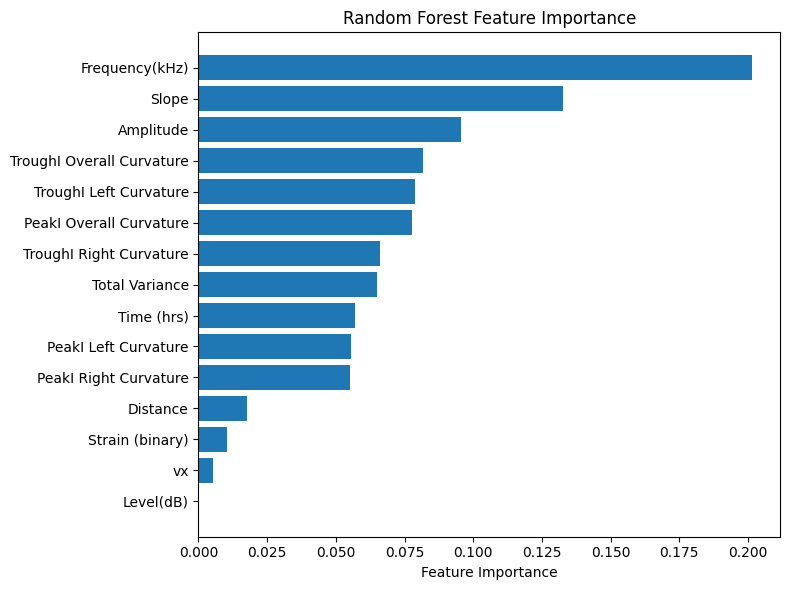

In [13]:
best_rf_model = rf_search.best_estimator_
feature_importance = best_rf_model.named_steps["rf"].feature_importances_
feature_names = best_rf_model.feature_names_in_

importance_df = pd.DataFrame(
    {"Feature": feature_names, "Importance": feature_importance}
).sort_values("Importance", ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(range(len(importance_df)), importance_df["Importance"])
plt.yticks(range(len(importance_df)), importance_df["Feature"])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Permutation Importance


Permutation Importance Rankings:
                      Feature  Importance_Mean  Importance_Std
6              Frequency(kHz)         0.149218        0.037506
1                       Slope         0.070479        0.020275
0                   Amplitude         0.035820        0.009499
14                 Time (hrs)         0.023538        0.009859
10      PeakI Right Curvature         0.010610        0.005669
7              Total Variance         0.005228        0.003096
2                    Distance         0.002564        0.001999
4                          vx         0.000041        0.001006
3                   Level(dB)         0.000000        0.000000
5             Strain (binary)         0.000000        0.000000
13    TroughI Right Curvature        -0.002397        0.003949
8        PeakI Left Curvature        -0.005307        0.003658
11     TroughI Left Curvature        -0.008637        0.009166
9     PeakI Overall Curvature        -0.013312        0.005914
12  TroughI Overall C

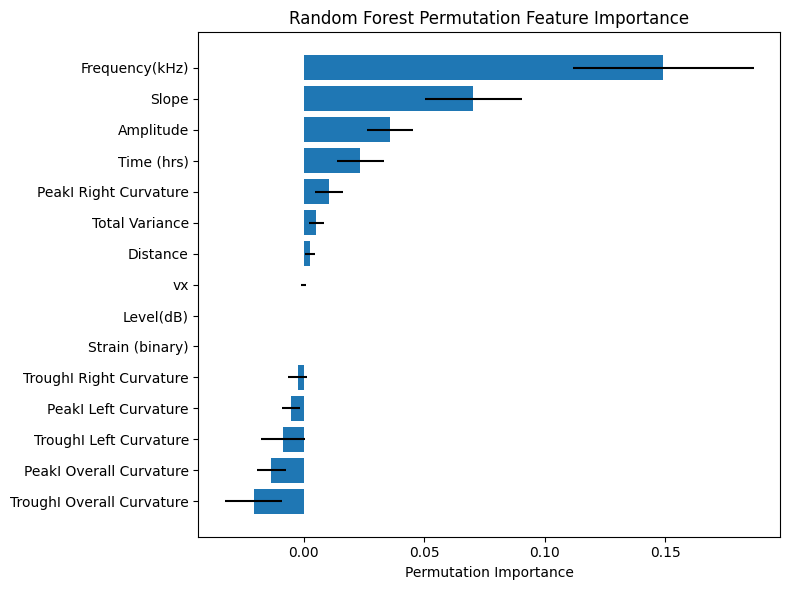

In [14]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    best_rf_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="r2",
)
perm_importance_df = pd.DataFrame(
    {
        "Feature": feature_names,
        "Importance_Mean": perm_importance.importances_mean,
        "Importance_Std": perm_importance.importances_std,
    }
).sort_values("Importance_Mean", ascending=False)

print("\nPermutation Importance Rankings:")
print(perm_importance_df)

# Plot permutation importance with error bars
plt.figure(figsize=(8, 6))
plt.barh(
    range(len(perm_importance_df)),
    perm_importance_df["Importance_Mean"],
    xerr=perm_importance_df["Importance_Std"],
)
plt.yticks(range(len(perm_importance_df)), perm_importance_df["Feature"])
plt.xlabel("Permutation Importance")
plt.title("Random Forest Permutation Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# SHAP

[Text(0, 0, 'Level(dB)'), Text(0, 1, 'vx'), Text(0, 2, 'Distance'), Text(0, 3, 'Strain (binary)'), Text(0, 4, 'PeakI Left Curvature'), Text(0, 5, 'TroughI Right Curvature'), Text(0, 6, 'Total Variance'), Text(0, 7, 'PeakI Right Curvature'), Text(0, 8, 'PeakI Overall Curvature'), Text(0, 9, 'TroughI Overall Curvature'), Text(0, 10, 'TroughI Left Curvature'), Text(0, 11, 'Amplitude'), Text(0, 12, 'Time (hrs)'), Text(0, 13, 'Slope'), Text(0, 14, 'Frequency(kHz)')]


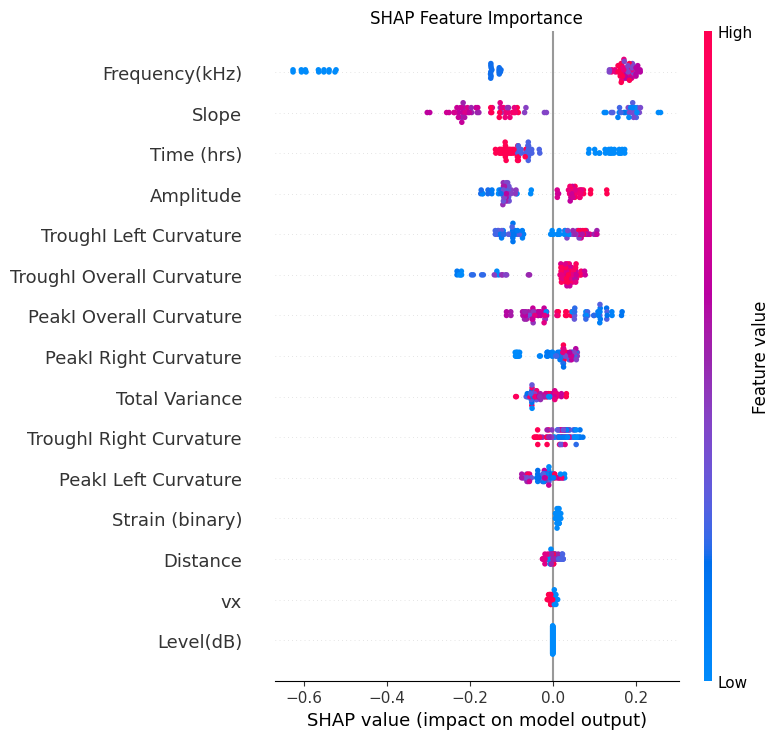

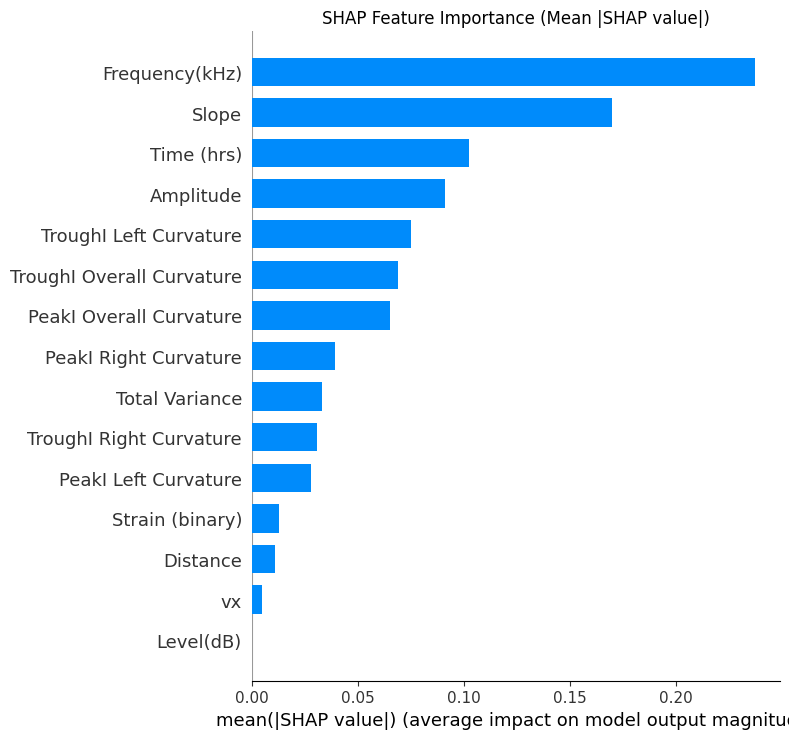

In [15]:
import shap

# Create SHAP explainer
explainer = shap.TreeExplainer(best_rf_model.named_steps["rf"])

# Get preprocessed test data
X_test_preprocessed = best_rf_model.named_steps["preprocessor"].transform(X_test)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test_preprocessed)

# Summary plot
plt.figure(figsize=(5, 4))
shap.summary_plot(
    shap_values, X_test_preprocessed, feature_names=feature_names, show=False
)
plt.title("SHAP Feature Importance")
print(plt.gca().get_yticklabels())
# plt.gca().set_yticklabels(feature_names, rotation=45)
plt.tight_layout()
plt.show()

# Bar plot of mean absolute SHAP values
plt.figure(figsize=(5, 4))
shap.summary_plot(
    shap_values,
    X_test_preprocessed,
    feature_names=feature_names,
    plot_type="bar",
    show=False,
)
plt.title("SHAP Feature Importance (Mean |SHAP value|)")
plt.tight_layout()
plt.show()

In [16]:
shap_interaction_values = explainer.shap_interaction_values(X_test_preprocessed)

In [17]:
def plot_shap_dependence(ft1, ft2):
    top_features = importance_df["Feature"].values
    feature_idx1 = list(feature_names).index(top_features[ft1])
    feature_idx2 = list(feature_names).index(top_features[ft2])

    # Main effects and interaction using shap.dependence_plot
    shap.dependence_plot(
        feature_idx1,
        shap_values,
        X_test_preprocessed,
        feature_names=feature_names,
        show=False,
    )
    plt.title(f"{top_features[ft1]} Main Effect")
    plt.figure(figsize=(3, 3))
    shap.dependence_plot(
        feature_idx2,
        shap_values,
        X_test_preprocessed,
        feature_names=feature_names,
        show=False,
    )
    plt.title(f"{top_features[ft2]} Main Effect")
    plt.figure(figsize=(3, 3))
    shap.dependence_plot(
        (feature_idx1, feature_idx2),
        shap_interaction_values,
        X_test_preprocessed,
        feature_names=feature_names,
        show=False,
        interaction_index=feature_idx2,
    )
    plt.title(f"{top_features[ft1]} x {top_features[ft2]} Interaction")

    plt.tight_layout()
    plt.show()

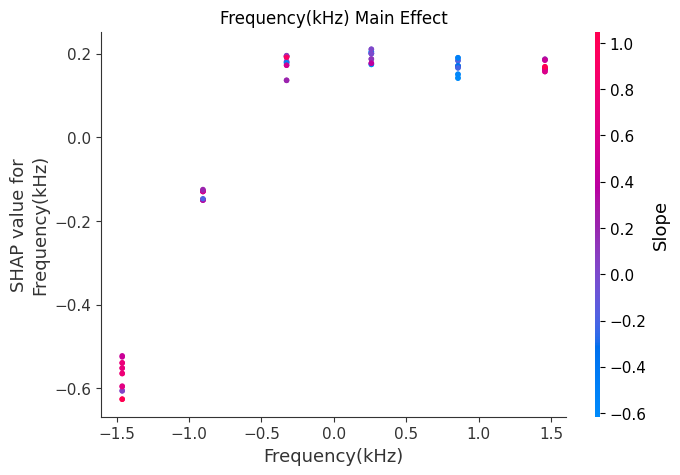

<Figure size 300x300 with 0 Axes>

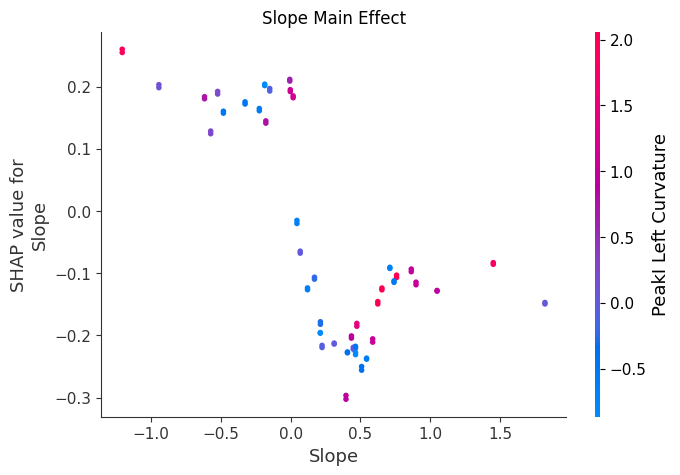

<Figure size 300x300 with 0 Axes>

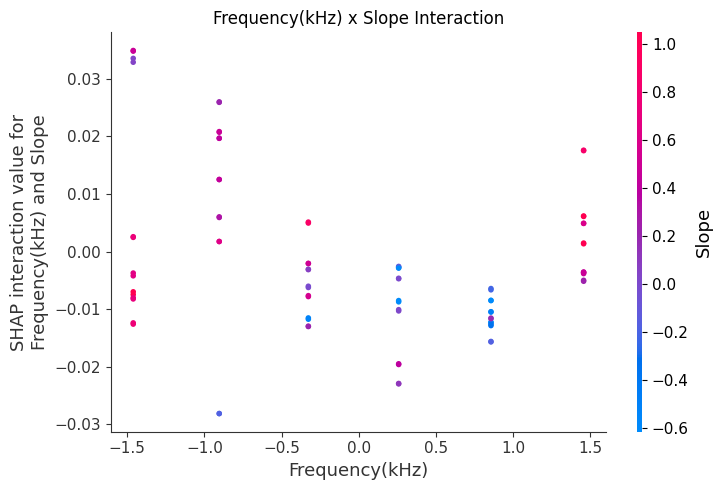

In [18]:
plot_shap_dependence(0, 1)

In [19]:
def plot_results(x, y, alpha=0.2, markersize=5, title="", color=None):
    if color is None:
        color = np.random.rand(
            3,
        )
        while np.mean(color) > 0.6:
            color = np.random.rand(
                3,
            )
    plt.plot(x, y, "o", alpha=alpha, markersize=markersize, color=color)
    plt.plot([5, 20], [5, 20], "k--", alpha=0.5)
    plt.axis("square")
    plt.xticks(np.arange(5, 21, 5))
    plt.yticks(np.arange(5, 21, 5))
    plt.xlim(5, 20)
    plt.ylim(5, 20)
    plt.title(title)
    plt.xlabel("GT # Synapses")
    plt.ylabel("Predicted # Synapses")

In [20]:
def train_plot_result(df, rf_pipeline):
    df = split_by_mouse(df)
    X_train, X_test, y_train, y_test, preprocessor = RF_data_prep(
        df, num_features, cat_features, log_features, minmax_features
    )
    dB_bins = [10, 20, 30, 40, 50, 60, 70, 80]
    plt.figure(figsize=(10, 4))

    color_palette = plt.cm.get_cmap("tab10", len(dB_bins) + 2)
    # iterate over dB levels:
    for dB in dB_bins:
        features = num_features + cat_features + log_features + minmax_features
        data = df[
            (df["Level(dB)"] >= dB) & (df["Level(dB)"] < dB + 10) & (df["Noise"] == 0)
        ]
        X = data[features]
        y = data["SynapsesPerIHC"]
        X_train1, X_test1, y_train1, y_test1 = (
            X[data.DataGroup != "Test"],
            X[data.DataGroup == "Test"],
            y[data.DataGroup != "Test"],
            y[data.DataGroup == "Test"],
        )
        if len(X_train1) > 0 and len(X_test1) > 0:
            rf_pipeline.fit(X_train1, y_train1)
            r2 = rf_pipeline.score(X_test1, y_test1)
            rmse = np.sqrt(np.mean((y_test1 - rf_pipeline.predict(X_test1)) ** 2))
            print(
                f"{dB}-{dB + 5} dB, {len(data)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}"
            )
            plt.subplot(2, 5, dB // 10)
            plot_results(
                y_test1,
                rf_pipeline.predict(X_test1),
                title=f"{dB}-{dB + 5} dB",
                color=color_palette(dB // 10 - 1),
            )
            # show R2 in lower right corner of plot:
            plt.text(
                19.75,
                5,
                f"R2: {r2:.2f}",
                fontsize=10,
                horizontalalignment="right",
                verticalalignment="bottom",
            )

    # run on all data:
    rf_pipeline.fit(X_train, y_train)
    r2 = rf_pipeline.score(X_test, y_test)
    rmse = np.sqrt(np.mean((y_test - rf_pipeline.predict(X_test)) ** 2))
    print(f"All data, {len(df)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}")
    plt.subplot(2, 5, 9)
    plot_results(
        y_test,
        rf_pipeline.predict(X_test),
        alpha=0.05,
        title=f"All",
        color=color_palette(-2),
    )
    plt.text(
        19.75,
        5,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    test_set = df[df["DataGroup"] == "Test"]
    test_set["RF predictions"] = rf_pipeline.predict(X_test)

    plt.text(
        19.75,
        5,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    plt.tight_layout()
    plt.show()

10-15 dB, 584 samples, R2: 0.062, RMSE: 1.602
20-25 dB, 782 samples, R2: 0.202, RMSE: 1.460
30-35 dB, 692 samples, R2: 0.235, RMSE: 1.428
40-45 dB, 532 samples, R2: 0.179, RMSE: 1.444
50-55 dB, 450 samples, R2: 0.206, RMSE: 1.420
60-65 dB, 434 samples, R2: 0.207, RMSE: 1.418
70-75 dB, 418 samples, R2: 0.172, RMSE: 1.461
80-85 dB, 402 samples, R2: 0.154, RMSE: 1.490
All data, 4294 samples, R2: 0.239, RMSE: 1.414


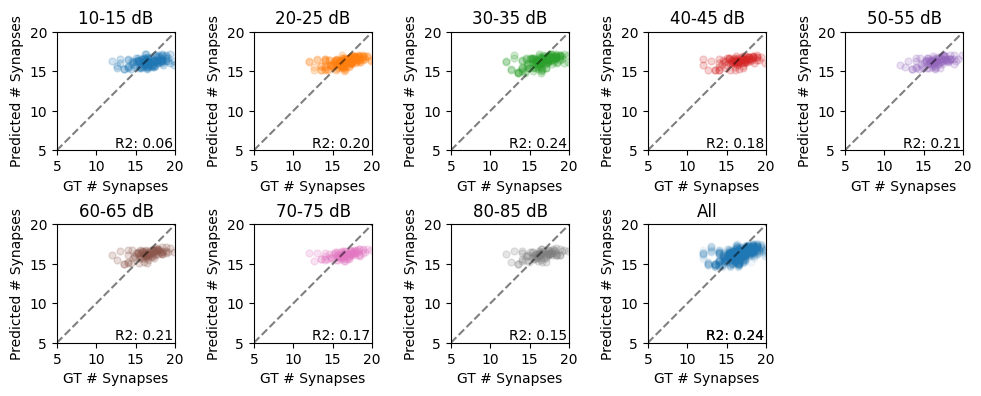

In [21]:
train_plot_result(final_clean_strained, best_rf_model)

Best RF score: 0.598, R2 on test set: 0.288
10-15 dB, 584 samples, R2: 0.093, RMSE: 1.574
20-25 dB, 782 samples, R2: 0.230, RMSE: 1.435
30-35 dB, 692 samples, R2: 0.202, RMSE: 1.459
40-45 dB, 532 samples, R2: 0.137, RMSE: 1.481
50-55 dB, 450 samples, R2: 0.332, RMSE: 1.302
60-65 dB, 434 samples, R2: 0.286, RMSE: 1.347
70-75 dB, 418 samples, R2: 0.300, RMSE: 1.343
80-85 dB, 402 samples, R2: 0.223, RMSE: 1.428
All data, 4294 samples, R2: 0.268, RMSE: 1.387


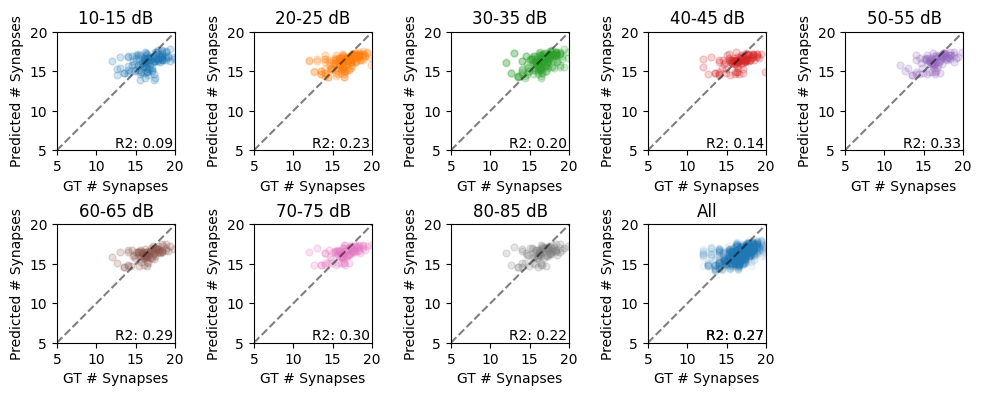

In [22]:
rf_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "rf",
            RandomForestRegressor(
                random_state=1,
                n_estimators=50,
                min_samples_split=30,
                min_samples_leaf=2,
                max_features=0.5,
                max_depth=30,
            ),
        ),
    ]
)
rf_pipeline.fit(X_train, y_train)
r2 = rf_pipeline.score(X_test, y_test)
print(
    f"Best RF score: {rf_pipeline.score(X_train, y_train):.3f}, R2 on test set: {r2:.3f}"
)
train_plot_result(final_clean_strained, rf_pipeline)

In [23]:
def train_plot_result_frequency(df, rf_pipeline):
    df = split_by_mouse(df)
    X_train, X_test, y_train, y_test, preprocessor = RF_data_prep(
        df, num_features, cat_features, log_features, minmax_features
    )
    freqs = sorted(X_train["Frequency(kHz)"].unique())
    plt.figure(figsize=(10, 4))

    color_palette = plt.cm.get_cmap("tab10", len(freqs) + 2)
    # iterate over dB levels:
    for i, frq in zip(range(len(freqs)), freqs):
        features = num_features + cat_features + log_features + minmax_features
        data = df[df["Frequency(kHz)"] == frq]
        X = data[features]
        y = data["SynapsesPerIHC"]
        X_train1, X_test1, y_train1, y_test1 = (
            X[data.DataGroup != "Test"],
            X[data.DataGroup == "Test"],
            y[data.DataGroup != "Test"],
            y[data.DataGroup == "Test"],
        )
        if len(X_train1) > 0 and len(X_test1) > 0:
            rf_pipeline.fit(X_train1, y_train1)
            r2 = rf_pipeline.score(X_test1, y_test1)
            rmse = np.sqrt(np.mean((y_test1 - rf_pipeline.predict(X_test1)) ** 2))
            print(f"{frq}Hz, {len(data)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}")
            plt.subplot(2, 4, i + 1)
            plot_results(
                y_test1,
                rf_pipeline.predict(X_test1),
                title=f"{frq}Hz",
                color=color_palette(i),
            )
            # show R2 in lower right corner of plot:
            plt.text(
                19.75,
                5,
                f"R2: {r2:.2f}",
                fontsize=10,
                horizontalalignment="right",
                verticalalignment="bottom",
            )

    # run on all data:
    rf_pipeline.fit(X_train, y_train)
    r2 = rf_pipeline.score(X_test, y_test)
    rmse = np.sqrt(np.mean((y_test - rf_pipeline.predict(X_test)) ** 2))
    print(f"All data, {len(df)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}")
    plt.subplot(2, 4, 7)
    plot_results(
        y_test,
        rf_pipeline.predict(X_test),
        alpha=0.05,
        title=f"All",
        color=color_palette(-2),
    )
    plt.text(
        19.75,
        5,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    test_set = df[df["DataGroup"] == "Test"]
    test_set["RF predictions"] = rf_pipeline.predict(X_test)

    plt.text(
        19.75,
        5,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    plt.tight_layout()
    plt.show()

8.0Hz, 734 samples, R2: 0.057, RMSE: 1.291
11.3Hz, 694 samples, R2: -0.023, RMSE: 0.668
16.0Hz, 694 samples, R2: -0.014, RMSE: 1.339
22.6Hz, 698 samples, R2: -0.297, RMSE: 1.312
32.0Hz, 722 samples, R2: -0.116, RMSE: 1.555
45.2Hz, 752 samples, R2: -0.359, RMSE: 1.738
All data, 4294 samples, R2: 0.239, RMSE: 1.414


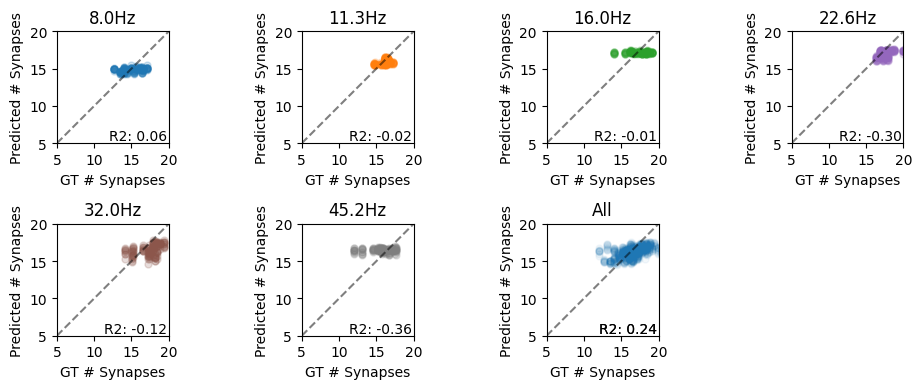

In [24]:
train_plot_result_frequency(final_clean_strained, best_rf_model)